In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

GPU available: True
GPU name: Tesla T4


In [ ]:
import zipfile

zip_path = "/content/archive-2.zip"
extract_path = "/content/flowers"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully")

Unzipped successfully


In [ ]:
import os

print(os.listdir("/content/flowers"))

print(os.listdir("/content/flowers/archive-2/dataset"))

['archive-2', '__MACOSX']
['test', 'train', 'valid', '.DS_Store']


In [ ]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dir = "/content/flowers/archive-2/dataset/train"
valid_dir = "/content/flowers/archive-2/dataset/valid"

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_data = datasets.ImageFolder(valid_dir, transform=valid_transforms)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=32)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(train_data.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs,1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    print(f"Epoch {epoch+1}")
    print("Train Loss:", running_loss/len(train_loader))
    print("Validation Accuracy:", correct/total)

Epoch 1
Train Loss: 2.632639821564279
Validation Accuracy: 0.8117359413202934
Epoch 2
Train Loss: 0.9163642368665555
Validation Accuracy: 0.8887530562347188
Epoch 3
Train Loss: 0.5543951867557153
Validation Accuracy: 0.8997555012224939
Epoch 4
Train Loss: 0.4067311072494926
Validation Accuracy: 0.9119804400977995
Epoch 5
Train Loss: 0.3191653634353382
Validation Accuracy: 0.9095354523227384


In [ ]:
torch.save(model.state_dict(), "/content/flower_model.pth")
print("Model saved.")

Model saved.


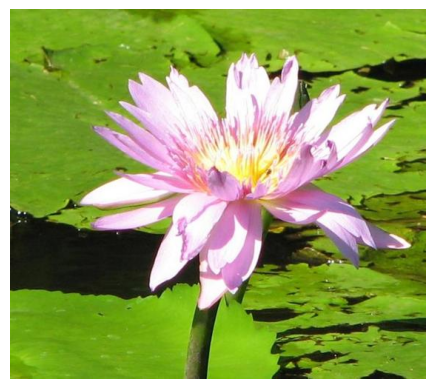

In [ ]:
# pick one image from the test folder
from PIL import Image
import matplotlib.pyplot as plt

test_image_path = "/content/flowers/archive-2/dataset/test/image_00365.jpg"

img = Image.open(test_image_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from torchvision import transforms
import torch

predict_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img_tensor = predict_transform(img).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    outputs = model(img_tensor)
    _, pred = torch.max(outputs, 1)

print("Predicted class index:", pred.item())

Predicted class index: 73


In [ ]:
print(train_data.class_to_idx)

{'1': 0, '10': 1, '100': 2, '101': 3, '102': 4, '11': 5, '12': 6, '13': 7, '14': 8, '15': 9, '16': 10, '17': 11, '18': 12, '19': 13, '2': 14, '20': 15, '21': 16, '22': 17, '23': 18, '24': 19, '25': 20, '26': 21, '27': 22, '28': 23, '29': 24, '3': 25, '30': 26, '31': 27, '32': 28, '33': 29, '34': 30, '35': 31, '36': 32, '37': 33, '38': 34, '39': 35, '4': 36, '40': 37, '41': 38, '42': 39, '43': 40, '44': 41, '45': 42, '46': 43, '47': 44, '48': 45, '49': 46, '5': 47, '50': 48, '51': 49, '52': 50, '53': 51, '54': 52, '55': 53, '56': 54, '57': 55, '58': 56, '59': 57, '6': 58, '60': 59, '61': 60, '62': 61, '63': 62, '64': 63, '65': 64, '66': 65, '67': 66, '68': 67, '69': 68, '7': 69, '70': 70, '71': 71, '72': 72, '73': 73, '74': 74, '75': 75, '76': 76, '77': 77, '78': 78, '79': 79, '8': 80, '80': 81, '81': 82, '82': 83, '83': 84, '84': 85, '85': 86, '86': 87, '87': 88, '88': 89, '89': 90, '9': 91, '90': 92, '91': 93, '92': 94, '93': 95, '94': 96, '95': 97, '96': 98, '97': 99, '98': 100, '99'

In [ ]:
idx_to_class = {v:k for k,v in train_data.class_to_idx.items()}
flower_folder = idx_to_class[pred.item()]

print("Predicted flower folder:", flower_folder)

Predicted flower folder: 73


In [ ]:
import json

with open("/content/flowers/archive-2/cat_to_name.json") as f:
    cat_to_name = json.load(f)

print("Predicted flower name:", cat_to_name[flower_folder])

Predicted flower name: water lily


(np.float64(-0.5), np.float64(642.5), np.float64(499.5), np.float64(-0.5))

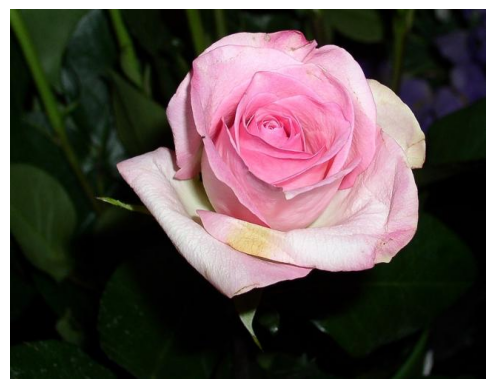

In [ ]:
rose_path = "/content/flowers/archive-2/dataset/test/image_01307.jpg"

rose_img = Image.open(rose_path).convert("RGB")

plt.imshow(rose_img)
plt.axis("off")

In [ ]:
from torchvision import transforms

predict_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

rose_tensor = predict_transform(rose_img)
rose_tensor = rose_tensor.unsqueeze(0).to(device)

In [ ]:
model.eval()

with torch.no_grad():
    outputs = model(rose_tensor)
    _, pred = torch.max(outputs, 1)

print("Predicted class index:", pred.item())

Predicted class index: 74


In [ ]:
idx_to_class = {v:k for k,v in train_data.class_to_idx.items()}

flower_folder = idx_to_class[pred.item()]

print("Flower name:", cat_to_name[flower_folder])

Flower name: rose


(np.float64(-0.5), np.float64(2925.5), np.float64(2999.5), np.float64(-0.5))

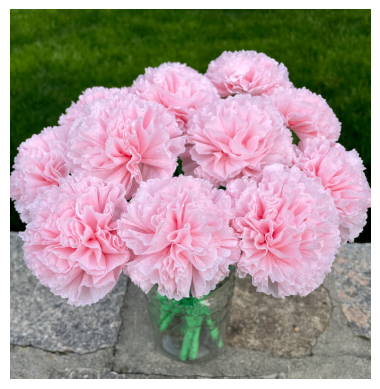

In [ ]:
my_flower = "/content/il_fullxfull.3119224107_eud1.jpg.avif"

my_flower = Image.open(my_flower).convert("RGB")

plt.imshow(my_flower)
plt.axis("off")

In [ ]:
predict_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

my_tensor = predict_transform(my_flower)
my_tensor = my_tensor.unsqueeze(0).to(device)

In [ ]:
model.eval()

with torch.no_grad():
    outputs = model(my_tensor)
    _, pred = torch.max(outputs, 1)

print("Predicted class index:", pred.item())

Predicted class index: 27


In [ ]:
idx_to_class = {v:k for k,v in train_data.class_to_idx.items()}

flower_folder = idx_to_class[pred.item()]

print("Flower name:", cat_to_name[flower_folder])

Flower name: carnation
